In [1]:
from pathlib import Path
from typing import Tuple, List
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
class Capability:
    def __init__(self, line, parent):
        #print(line)
        _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.boundsOffset = int(boundsOffset, 16)
        self.boundsLength = int(boundsLength, 16)
        self.boundsVirtBase = int(boundsVirtualBase, 16)
        self.capPerms = int(capPerms, 2)
        self.parent = parent

    def capKey(self):
        return (self.boundsVirtBase, self.boundsLength)
    
    def __eq__(self, other):
        return self.boundsOffset == other.boundsOffset and self.boundsLength == other.boundsLength and self.boundsVirtBase == other.boundsVirtBase and self.capPerms == other.capPerms

    def __hash__(self):
        return hash((self.boundsOffset, self.boundsLength, self.boundsVirtBase, self.capPerms))
    
    def __repr__(self):
        return f"Cap virtBase {self.boundsVirtBase} length {self.boundsLength} offset {self.boundsOffset}"

class ReportAccessLog:
    def __init__(self, line):
        #44200 Prefetcher logReportAccess level 1 addr 00000000c0007648 pcHash c0000260 hitMiss 1 boundsOffset 0000000000000008 boundsLength 0000000000002f30 boundsVirtBase 00000000c0007640 capPerms 0000000000001111000111111010111

        #print(line.split())
        clock_time,_, _, _, level, _, addr, _, pcHash, _, isMiss, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.clock_time = int(clock_time)
        self.level = int(level)
        self.addr = int(addr, 16)
        self.pcHash = int(pcHash, 16)
        self.isMiss = int(isMiss)

        
        self.cap = Capability("boundsOffset"+line.partition("boundsOffset")[2], self)
    
class ReportDataArrivalCap:
    def __init__(self, line, parent):
        pre, _, cap = line.partition("boundsOffset")
        _, _, _, _, index, _, tag, _, addr = pre.split()
        self.index = int(index)
        self.tag = bool(int(tag))
        self.addr = int(addr, 16)
        if self.tag:
            self.cap = Capability("boundsOffset"+cap, self)
        self.parent = parent

class ReportDataArrival:
    def __init__(self, line):
        clock_time,_, _, _, level, _, requestAddr, _, pcHash, _, wasMiss, _, wasPrefetch, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.clock_time = int(clock_time)
        self.level = int(level)
        self.requestAddr = int(requestAddr, 16)
        self.pcHash = int(pcHash, 16)
        self.wasMiss = int(wasMiss)
        self.wasPrefetch = int(wasPrefetch)
        self.requestCap = Capability("boundsOffset"+line.partition("boundsOffset")[2], self)
        self.capabilites: List[ReportDataArrivalCap] = []

    def add_capability(self, line, parent_data_arrivals):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.capabilites.append(capability)
            parent_data_arrivals[capability.cap.capKey()] = capability.cap 

        return capability




def parse_log(input_file) -> Tuple[List[ReportAccessLog], List[ReportDataArrival], List[ReportAccessLog]]:
    recent_misses = set()
    parent_access = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    parent_data_arrivals = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    accesses = []
    data_arrivals = []
    access_misses = []

    with open(input_file, "r") as fp:
        while True:
            line = fp.readline()
            if not line:
                break

            if "logReportAccess" in line:
                reportAccess = ReportAccessLog(line)

                if reportAccess.isMiss:
                    recent_misses.add(reportAccess.addr)
                    access_misses.append(reportAccess)
                elif reportAccess.addr in recent_misses:
                    #Skip first hit access after miss
                    recent_misses.remove(reportAccess.addr)
                    continue

                accesses.append(reportAccess)
                parent_access[reportAccess.cap.capKey()] = reportAccess.cap

                if reportAccess.cap.capKey() in parent_data_arrivals:
                    parent = parent_data_arrivals[reportAccess.cap.capKey()]
                    reportAccess.parent = parent
                    #parent.child = reportAccess
                    #print("found parent")

                # if reportAccess.cap.boundsLength == 40000:
                #         print("40000 arrival")
                #         print(reportAccess.cap.capKey())
                #print(reportAccess.cap.boundsLength)
            
            elif "logReportDataArrival" in line:
                data_arrival = ReportDataArrival(line)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrivals.append(data_arrival)

                parent_data_arrivals[data_arrival.cap.capKey()] = data_arrival
                if data_arrival.requestCap.capKey() in parent_access:
                    # if data_arrival.requestCap.boundsLength == 40000:
                    #     print("40000 arrival in arrival")
                    parent = parent_access[data_arrival.requestCap.capKey()]
                    data_arrival.parent = parent
                    #parent.child = data_arrival
                    #print("found parent2")

                # if data_arrival.requestCap.boundsLength == 40000:
                #     print(data_arrival.requestCap.capKey())
                    


    print(f"access {len(accesses)} misses {len(access_misses)}")
    return accesses, data_arrivals, access_misses

In [3]:
#input_file = Path("../simulations/adpcm_decode") / "sim_0.0" / "sim_stdout"
input_file = Path("../simulations/dijkstra") / "sim_0.0" / "sim_stdout"

accesses, data_arrivals, access_misses = parse_log(input_file)

access 3473622 misses 50219


In [4]:
size_miss = defaultdict(int)
size_total = defaultdict(int)
virtual_addr = defaultdict(int)
virt_size_pair = defaultdict(int)
size_virt_set = defaultdict(set)

miss_caps = defaultdict(int)

seen_before_request_cap = set()
seen_before_cap_cacheline = set()

how_many_cache_lines = defaultdict(set)

size_access = defaultdict(int)

offsets_access_size = defaultdict(set)
offsets_seen_size = defaultdict(set)

for i, data_arrival in enumerate(data_arrivals):

    # if data_arrival.requestCap in seen_before_request_cap:
    #     #print(data_arrival.requestCap.boundsVirtBase)
    #     #print("Same cache line accessed")
    #     continue
    # #print(data_arrival.wasMiss)

    # seen_before_request_cap.add(data_arrival.requestCap)

    #print(i)
    size_access[data_arrival.requestCap.boundsLength] += 1
    offsets_access_size[data_arrival.requestCap.boundsLength].add(data_arrival.requestCap.boundsOffset)

    if data_arrival.wasMiss:
        size_miss[data_arrival.requestCap.boundsLength] += 1
        miss_caps[data_arrival.requestCap] += 1
        #print("miss")


    for capLine in data_arrival.capabilites:
        # if capLine.cap in seen_before_cap_cacheline:
        #     # print("same cap in multiple cache lines")
        #     # #print(data_arrival.requestAddr)
        #     # print(capLine.addr)
        # else:
        seen_before_cap_cacheline.add(capLine.cap)

        how_many_cache_lines[capLine.cap].add(data_arrival.requestCap)
        
        
        size_total[capLine.cap.boundsLength] += 1
        virtual_addr[capLine.cap.boundsVirtBase] += 1
        virt_size_pair[capLine.cap.boundsVirtBase, capLine.cap.boundsLength] += 1
        size_virt_set[capLine.cap.boundsLength].add(capLine.cap.boundsVirtBase)
        offsets_seen_size[capLine.cap.boundsLength].add(capLine.cap.boundsOffset)

In [20]:
i = 0
for data_arrival in data_arrivals:
    if hasattr(data_arrival.parent.parent, 'parent'):
        print(f"parent: {data_arrival.parent.parent.parent}       child: {data_arrival.requestCap}")
        i += 1
    if i > 10:
        break

parent: Cap virtBase 3221251344 length 16 offset 0       child: Cap virtBase 3221251344 length 16 offset 0
parent: Cap virtBase 3221251328 length 16 offset 0       child: Cap virtBase 3221251328 length 16 offset 0
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 0
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 1
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 2
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 3
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 4
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 5
parent: Cap virtBase 3221309629 length 23 offset 0       child: Cap virtBase 3221309629 length 23 offset 4
parent: Cap virtBase 3221309629 lengt

In [5]:
len(seen_before_cap_cacheline)

952

# Does a capability which is repeated in multiple cache lines (distringihs this) perform cluster with miss and non miss. x = number of time cache line is seen. y = miss or not

In [85]:
multiple_cache_lines = {k: len(v) for k, v in how_many_cache_lines.items()}
multiple_missess = [miss_caps[k] for k in how_many_cache_lines.keys()]
size = [k.boundsLength for k in how_many_cache_lines.keys()]

In [86]:
df = pd.DataFrame(data={"Cap": multiple_cache_lines.keys(), "Count": multiple_cache_lines.values(), "miss_count": multiple_missess, "size":size})
df = df.sort_values("size")
df

,Cap,Count,miss_count,size
22,Cap virtBase 3221311044 length 4 offset 0,4,0,4
23,Cap virtBase 3221311036 length 4 offset 0,4,0,4
21,Cap virtBase 3221311040 length 4 offset 0,4,0,4
19,Cap virtBase 3221311032 length 4 offset 0,4,0,4
18,Cap virtBase 3221311028 length 4 offset 0,4,1,4
...,...,...,...,...
9,Cap virtBase 0 length 3225419776 offset 322160...,23,0,3225419776
932,Cap virtBase 0 length 36893488147419103231 off...,2,0,36893488147419103231
11,Cap virtBase 0 length 36893488147419103231 off...,2,0,36893488147419103231
7,Cap virtBase 0 length 36893488147419103231 off...,1,0,36893488147419103231


<Axes: xlabel='size'>

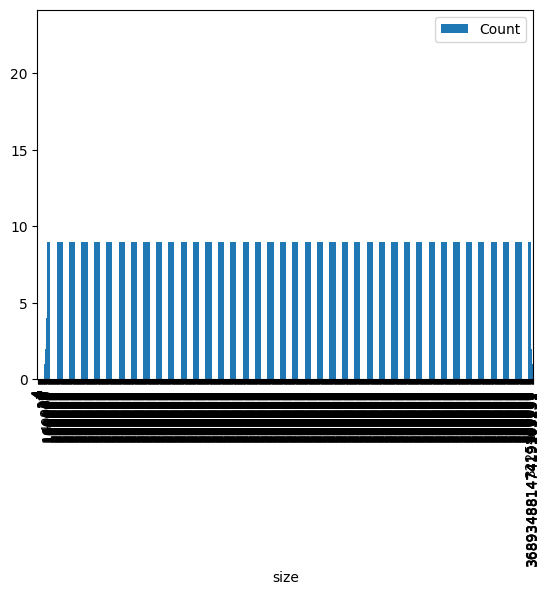

In [87]:
df.plot(kind="bar", x="size",y="Count")

# Number of different capabilites for each size.

In [88]:
size_virt_set

defaultdict(set,
            {16: {(3221251328, 16), (3221251344, 16), (3221311488, 16)},
             80: {(3221311232, 80)},
             37: {(3221309592, 37), (3221309652, 37)},
             36893488147419103231: {(0, 36893488147419103231)},
             7: {(3221309689, 7)},
             23: {(3221309629, 23)},
             3225419776: {(0, 3225419776)},
             32: {(1647312896, 32)},
             4: {(3221311016, 4),
              (3221311020, 4),
              (3221311024, 4),
              (3221311028, 4),
              (3221311032, 4),
              (3221311036, 4),
              (3221311040, 4),
              (3221311044, 4)},
             160000: {(3221311744, 160000)},
             800: {(3221471744, 800)},
             40000: {(3221251392, 40000)}})

In [89]:
df= pd.DataFrame.from_dict({k:[len(v)] for k, v in size_virt_set.items()}).transpose()
df = df.sort_index()

<Axes: xlabel='Capability size', ylabel='Number of unique capabilites'>

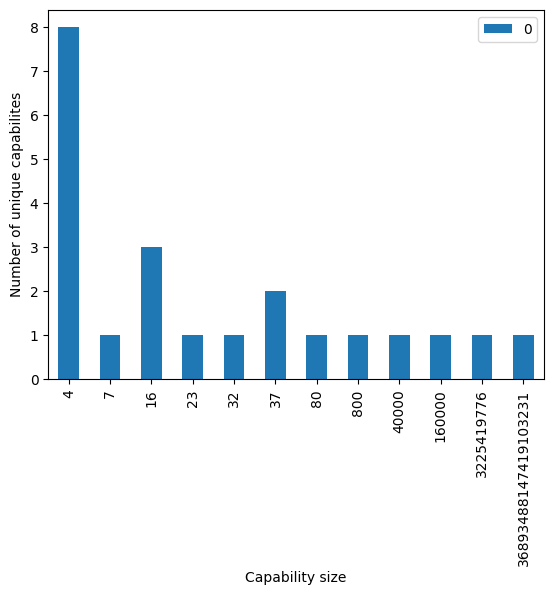

In [90]:
df.plot(kind="bar", xlabel="Capability size", ylabel="Number of unique capabilites")

# Number of misses for each size

In [99]:
def set_dict_to_count(set_dict):
    return {k: len(v) for k,v in set_dict.items()}

In [79]:
def plot_count(count_dict: dict, xlabel, ylabel):
    df = pd.DataFrame(data = {"key": count_dict.keys(), "value": count_dict.values()})
    df = df.sort_values("key")
    df.plot(kind="bar", x="key", y="value", xlabel=xlabel, ylabel=ylabel)

In [80]:
sum(size_miss.values())

50219

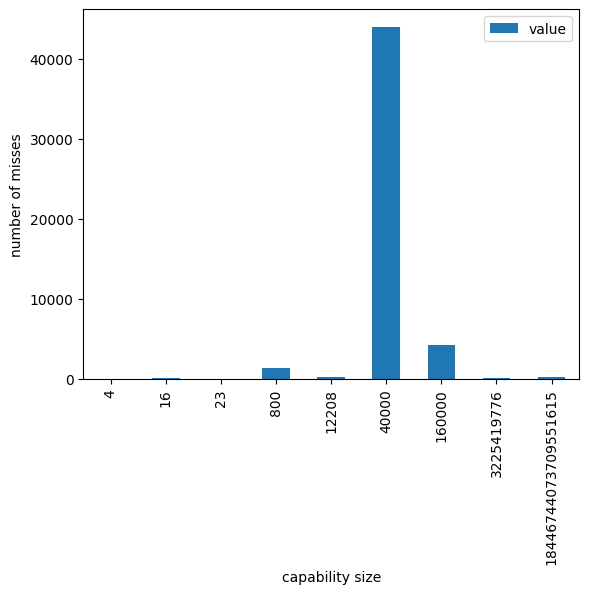

In [91]:
plot_count(size_miss, "capability size", "number of misses")

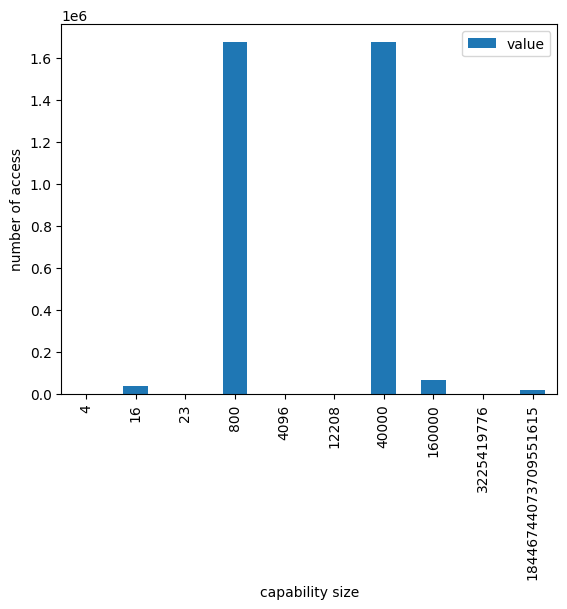

In [94]:
plot_count(size_access, "capability size", "number of access")

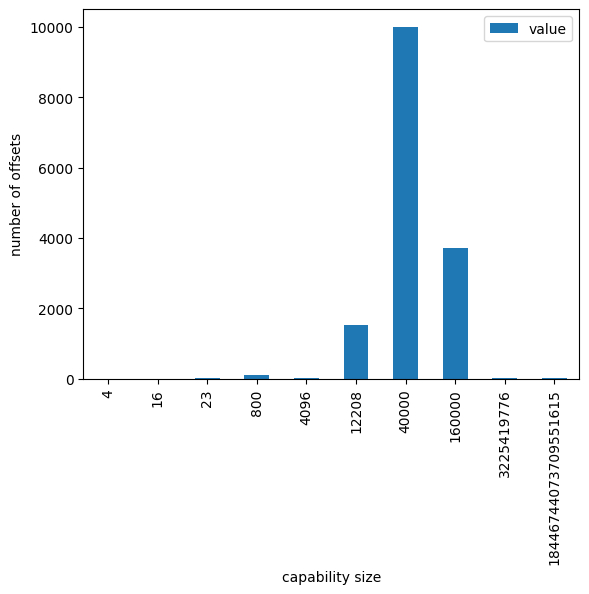

In [100]:
plot_count(set_dict_to_count(offsets_access_size), "capability size", "number of offsets")

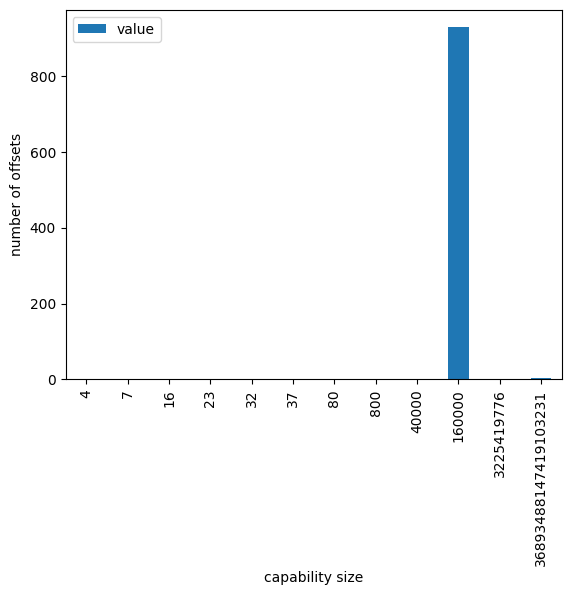

In [102]:
plot_count(set_dict_to_count(offsets_seen_size), "capability size", "number of offsets")

In [52]:
dict(sorted(size_miss.items(), key=lambda item: item[1], reverse=True))

{40000: 44009,
 160000: 4256,
 800: 1399,
 12208: 192,
 18446744073709551615: 174,
 16: 98,
 3225419776: 89,
 23: 1,
 4: 1}

In [53]:
dict(sorted(size_total.items(), key=lambda item: item[1], reverse=True))

{160000: 167802,
 4: 50668,
 40000: 16720,
 16: 168,
 800: 92,
 36893488147419103231: 72,
 37: 27,
 80: 26,
 3225419776: 24,
 32: 23,
 7: 1,
 23: 1}

In [14]:
class SizePrefetcher:
    def __init__(self):
        self.miss_count = defaultdict(int)
        self.total_count = defaultdict(int)
        self.correctly_predicted = 0
    
    def reportDataArrival(self, reportDataArrival: ReportDataArrival):
        if reportDataArrival.wasMiss:
            self.miss_count[reportDataArrival.requestCap.boundsLength] += 1

        self.total_count[reportDataArrival.cap1.boundsLength] += 1
        self.total_count[reportDataArrival.cap2.boundsLength] += 1
        self.total_count[reportDataArrival.cap3.boundsLength] += 1
        self.total_count[reportDataArrival.cap4.boundsLength] += 1

    def __str__(self):
        return str(self.miss_count) + str(self.total_count)


# class SizeOffsetPrefetcher:
#     sizeoffsetmap = {}
#     def reportAccess(self, reportAccess):

#         reportAccess
# We want to take in reportAccess, reportDataArrival, generatePrefetech, check if prefetcher is correct, take in misses 